# Final Project — Optimizing a Classifier on the Breast Cancer Dataset

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

This project runs one dataset through the whole course: clustering it without labels, compressing it with PCA, and then fitting the same logistic regression seven different ways — with scikit-learn, with five hand-written gradient methods, and with a genetic algorithm. Because every optimizer minimizes the *same* convex loss, the comparison answers a precise question: do they find the same solution, and what does each one cost to get there?

In [1]:
# Environment setup & imports
try:
    import pygad
except ImportError:
    !pip install -q pygad
    import pygad

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix, f1_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

## Step 1: Load the Data

569 patients, 30 features, two classes. The features are ten characteristics of cell nuclei — radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension — each reported as a mean, a standard error and a "worst" value.

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

feature_names = list(data.feature_names)
class_names = list(data.target_names)

print(f"Features: {X.shape[0]} samples x {X.shape[1]} features")
print(f"Target encoding: {dict(enumerate(class_names))}")
print(pd.Series(y).map(dict(enumerate(class_names))).value_counts().to_string())
print(f"\nMissing values: {np.isnan(X).sum()}")

Features: 569 samples x 30 features
Target encoding: {0: np.str_('malignant'), 1: np.str_('benign')}
benign       357
malignant    212

Missing values: 0


Note the encoding: `0` is *malignant* and `1` is *benign*. For a diagnostic test the costly error is a malignant case called benign — a false negative in medical terms — which is the lower-left cell of every confusion matrix below.

The data is split before anything is fitted, and the scaler is fitted on the training part only so that no information from the test set leaks into the preprocessing.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, test: {X_test.shape}")
print(f"Class balance in train: {np.bincount(y_train)}, in test: {np.bincount(y_test)}")

Train: (426, 30), test: (143, 30)
Class balance in train: [159 267], in test: [53 90]


## Step 2: Pairwise Scatter Plots Against the Target

All 30 features would make a grid of 900 panels. The ten `mean ...` features are shown instead — the error and worst variants describe the same ten characteristics — with the class as colour.

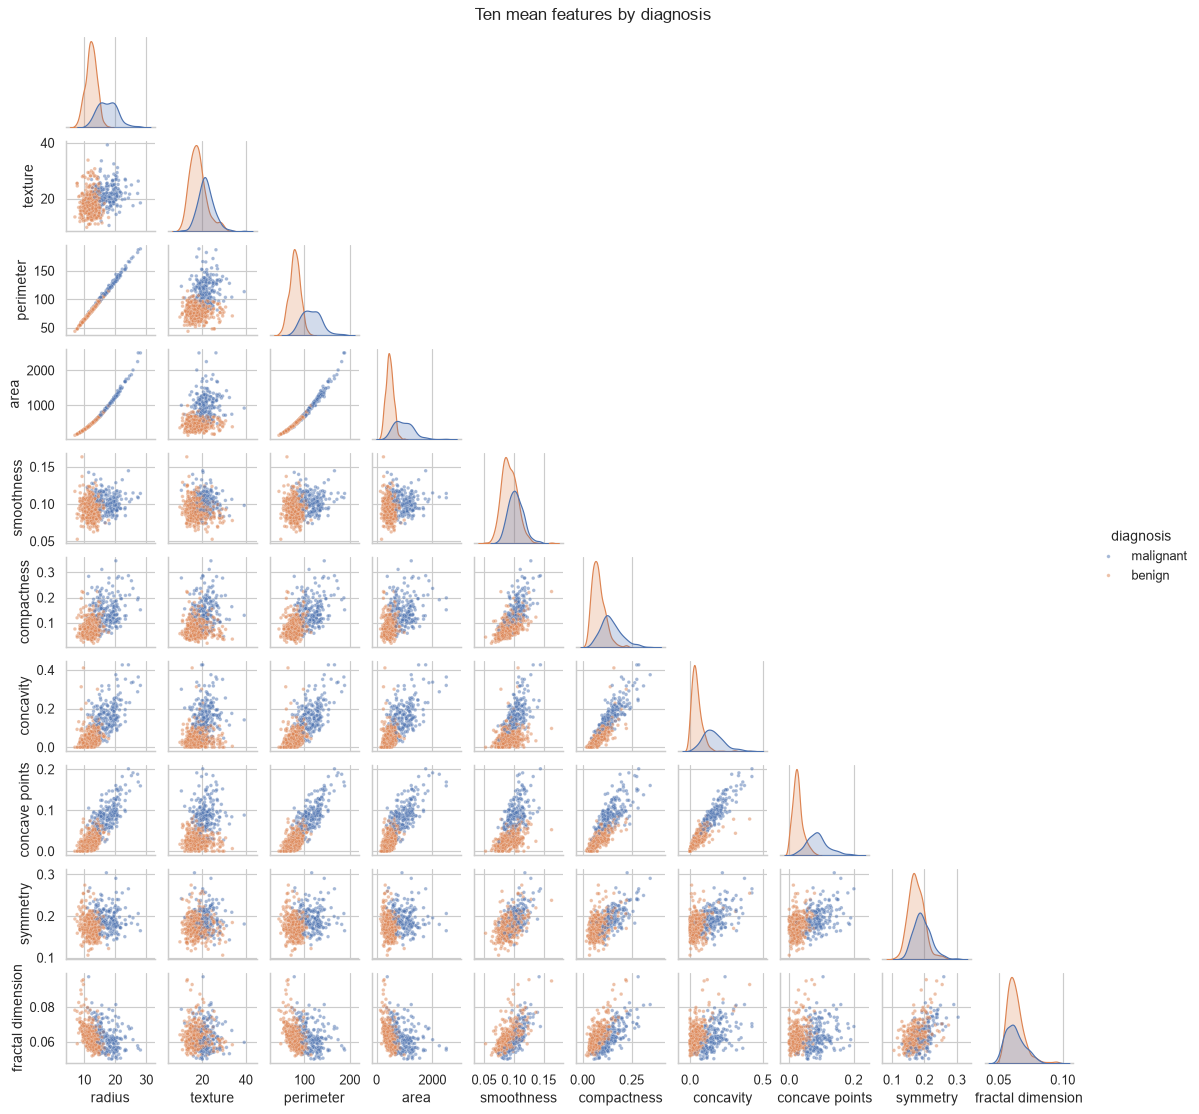

In [4]:
mean_features = [name for name in feature_names if name.startswith("mean")]

pair_data = pd.DataFrame(X[:, [feature_names.index(name) for name in mean_features]],
                         columns=[name.replace("mean ", "") for name in mean_features])
pair_data["diagnosis"] = [class_names[label] for label in y]

sns.pairplot(pair_data, hue="diagnosis", corner=True, height=1.3,
             plot_kws={"s": 9, "alpha": 0.5}, diag_kind="kde")
plt.suptitle("Ten mean features by diagnosis", y=1.01)
plt.show()

The classes overlap but are clearly displaced: malignant samples sit at larger radius, perimeter, area, concavity and concave points. Several panels are almost straight lines — `radius`, `perimeter` and `area` are geometrically the same measurement, which is the redundancy PCA exploits in Step 4.

## Step 3: Clustering Without the Labels

Three methods are given the standardized features and asked for two groups. Cluster numbering is arbitrary, so each result is matched to the true classes with the Hungarian algorithm before the confusion matrix is read.

In [5]:
X_all_scaled = StandardScaler().fit_transform(X)


def align_clusters(y_true, labels):
    """Relabel clusters so that they line up with the true classes as well as possible."""
    overlap = confusion_matrix(y_true, labels)
    rows, columns = linear_sum_assignment(-overlap)
    mapping = dict(zip(columns, rows))
    return np.array([mapping[label] for label in labels])


CLUSTERERS = {
    "KMeans": KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE),
    "Gaussian mixture": GaussianMixture(n_components=2, n_init=10, random_state=RANDOM_STATE),
    "Spectral clustering": SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                              n_neighbors=10, random_state=RANDOM_STATE),
}

clustering_results = {}
rows = []
for name, model in CLUSTERERS.items():
    labels = model.fit_predict(X_all_scaled)
    aligned = align_clusters(y, labels)
    clustering_results[name] = aligned

    matrix = confusion_matrix(y, aligned)
    rows.append({
        "method": name,
        "ARI": adjusted_rand_score(y, labels),
        "accuracy": accuracy_score(y, aligned),
        "F1": f1_score(y, aligned),
        "malignant missed": int(matrix[0, 1]),
        "benign misflagged": int(matrix[1, 0]),
    })

pd.DataFrame(rows).round(4)

,method,ARI,accuracy,F1,malignant missed,benign misflagged
0,KMeans,0.6536,0.9051,0.9262,36,18
1,Gaussian mixture,0.7740,0.9402,0.9522,16,18
2,Spectral clustering,0.7608,0.9367,0.9512,30,6


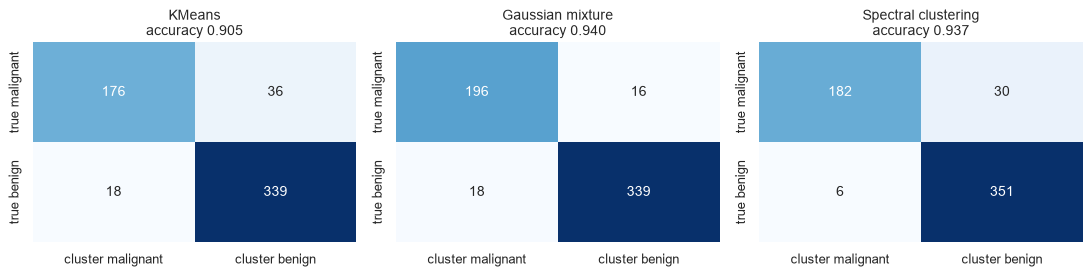

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (name, aligned) in zip(axes, clustering_results.items()):
    matrix = pd.DataFrame(confusion_matrix(y, aligned),
                          index=[f"true {n}" for n in class_names],
                          columns=[f"cluster {n}" for n in class_names])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\naccuracy {accuracy_score(y, aligned):.3f}")

plt.tight_layout()
plt.show()

**Interpretation.** All three recover the diagnosis to a useful degree without ever seeing a label, which says the two classes occupy genuinely different regions of the feature space — a good sign for the classifiers that follow.

They differ in how they carve that space, and the ranking follows directly from their assumptions. **KMeans** is the weakest (90.5%) because it looks for spherical clusters of similar size, and these two are neither: the malignant group is more spread out and smaller. The **Gaussian mixture** is the strongest (94.0%) precisely because it drops both assumptions — each component gets its own covariance matrix, so it can fit an elongated malignant cloud and a compact benign one. **Spectral clustering** (93.7%) works from a $k$-nearest-neighbour graph and so does not care about cluster shape at all, but it is more sensitive to the points in the overlap zone between the classes.

The error pattern is the same for all three and matters medically: the mistakes are concentrated on malignant cases labelled benign — 36 of them for KMeans, 16 for the mixture. Unsupervised structure alone is not a diagnostic tool, which is the argument for the supervised models in Steps 6–8.

## Step 4: Dimensionality Reduction with PCA

The features are heavily correlated, so most of their variance lives in far fewer than 30 directions. The number of components is chosen by the 95% threshold rather than fixed in advance.

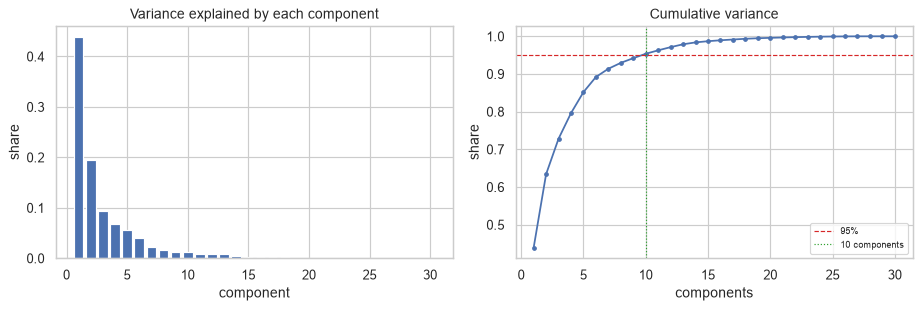

10 components keep 95.4% of the variance
The first two alone keep 63.4%
Feature space: 30 -> 10 dimensions


In [7]:
pca_full = PCA().fit(X_train_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cumulative, 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_)
axes[0].set(title="Variance explained by each component", xlabel="component", ylabel="share")

axes[1].plot(range(1, 31), cumulative, marker="o", markersize=3)
axes[1].axhline(0.95, color="tab:red", linestyle="--", linewidth=1, label="95%")
axes[1].axvline(n_components, color="tab:green", linestyle=":", linewidth=1,
                label=f"{n_components} components")
axes[1].set(title="Cumulative variance", xlabel="components", ylabel="share")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components, random_state=RANDOM_STATE).fit(X_train_scaled)
Z_train = pca.transform(X_train_scaled)
Z_test = pca.transform(X_test_scaled)

print(f"{n_components} components keep {cumulative[n_components - 1]:.1%} of the variance")
print(f"The first two alone keep {cumulative[1]:.1%}")
print(f"Feature space: {X_train_scaled.shape[1]} -> {Z_train.shape[1]} dimensions")

## Step 5: The Classes in the New Feature Space

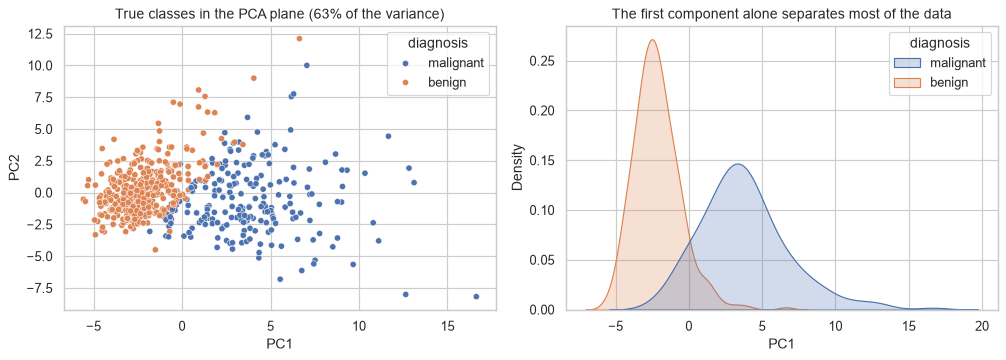

In [8]:
Z_all = pca.transform(StandardScaler().fit(X_train).transform(X))

plot_data = pd.DataFrame({"PC1": Z_all[:, 0], "PC2": Z_all[:, 1],
                          "diagnosis": [class_names[label] for label in y]})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.scatterplot(data=plot_data, x="PC1", y="PC2", hue="diagnosis", s=28, ax=axes[0])
axes[0].set_title(f"True classes in the PCA plane ({cumulative[1]:.0%} of the variance)")

sns.kdeplot(data=plot_data, x="PC1", hue="diagnosis", fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("The first component alone separates most of the data")
plt.tight_layout()
plt.show()

Two components are enough to see the structure: the classes form two clouds that a straight line would separate with few mistakes, overlapping only in a narrow band. The second panel shows that most of that separation is carried by PC1 alone — which is why a linear classifier is a reasonable choice here, and why it will work on the compressed features almost as well as on the original thirty.

## Step 6: Logistic Regression with scikit-learn

The baseline, fitted on the 10 principal components.

In [9]:
def report(name, y_pred, train_loss=np.nan, cost="", comment=""):
    """Collect the quality metrics the task asks for."""
    matrix = confusion_matrix(y_test, y_pred)
    return {"model": name,
            "F1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
            "malignant missed": int(matrix[0, 1]),
            "benign misflagged": int(matrix[1, 0]),
            "train log loss": train_loss,
            "cost": cost,
            "note": comment}


sklearn_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE).fit(Z_train, y_train)
sklearn_pred = sklearn_model.predict(Z_test)

print(confusion_matrix(y_test, sklearn_pred))
print(f"\nF1 = {f1_score(y_test, sklearn_pred):.4f}, accuracy = {accuracy_score(y_test, sklearn_pred):.4f}")

[[52  1]
 [ 2 88]]

F1 = 0.9832, accuracy = 0.9790


## Step 7: Logistic Regression Trained by Gradient Descent

Logistic regression models the probability of the positive class as

$$p(x) = \sigma(w^{T}x), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

and fits $w$ by minimizing the average cross-entropy

$$L(w) = -\frac{1}{n}\sum_i \left[ y_i \log p(x_i) + (1 - y_i)\log(1 - p(x_i)) \right],
\qquad \nabla L(w) = \frac{1}{n} X^{T}\left(\sigma(Xw) - y\right)$$

This loss is convex, so every optimizer below is aiming at the same single minimum — which is what makes them directly comparable. The five methods are the ones implemented in Homework 5, now applied to a classification loss instead of a regression one.

In [10]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def add_bias(Z):
    return np.hstack([np.ones((len(Z), 1)), Z])


A_train, A_test = add_bias(Z_train), add_bias(Z_test)
N_WEIGHTS = A_train.shape[1]


def log_loss(w, A=A_train, target=y_train):
    probabilities = sigmoid(A @ w)
    epsilon = 1e-12
    return -np.mean(target * np.log(probabilities + epsilon)
                    + (1 - target) * np.log(1 - probabilities + epsilon))


def gradient(w, A=A_train, target=y_train):
    return A.T @ (sigmoid(A @ w) - target) / len(target)


def predict(w, A=A_test):
    return (sigmoid(A @ w) >= 0.5).astype(int)


print(f"Weights to fit: {N_WEIGHTS} (bias + {n_components} components)")
print(f"Loss at w = 0: {log_loss(np.zeros(N_WEIGHTS)):.6f}")

Weights to fit: 11 (bias + 10 components)
Loss at w = 0: 0.693147


In [11]:
def gradient_descent(learning_rate=1.0, n_iterations=5000):
    w = np.zeros(N_WEIGHTS)
    history = np.empty(n_iterations + 1)
    for i in range(n_iterations):
        history[i] = log_loss(w)
        w -= learning_rate * gradient(w)
    history[-1] = log_loss(w)
    return w, history


def stochastic_gradient_descent(learning_rate=0.05, n_iterations=100, seed=0):
    w = np.zeros(N_WEIGHTS)
    history = np.empty(n_iterations + 1)
    rng = np.random.default_rng(seed)
    for i in range(n_iterations):
        history[i] = log_loss(w)
        for j in rng.permutation(len(y_train)):
            row = A_train[j]
            w -= learning_rate * row * (sigmoid(row @ w) - y_train[j])
    history[-1] = log_loss(w)
    return w, history


def rmsprop(learning_rate=0.01, n_iterations=2000, beta=0.9, eps=1e-8):
    w = np.zeros(N_WEIGHTS)
    square_average = np.zeros(N_WEIGHTS)
    history = np.empty(n_iterations + 1)
    for i in range(n_iterations):
        history[i] = log_loss(w)
        g = gradient(w)
        square_average = beta * square_average + (1 - beta) * g**2
        w -= learning_rate * g / (np.sqrt(square_average) + eps)
    history[-1] = log_loss(w)
    return w, history


def adam(learning_rate=0.1, n_iterations=2000, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.zeros(N_WEIGHTS)
    first = np.zeros(N_WEIGHTS)
    second = np.zeros(N_WEIGHTS)
    history = np.empty(n_iterations + 1)
    for i in range(1, n_iterations + 1):
        history[i - 1] = log_loss(w)
        g = gradient(w)
        first = beta1 * first + (1 - beta1) * g
        second = beta2 * second + (1 - beta2) * g**2
        w -= learning_rate * (first / (1 - beta1**i)) / (np.sqrt(second / (1 - beta2**i)) + eps)
    history[-1] = log_loss(w)
    return w, history


def nadam(learning_rate=0.1, n_iterations=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.zeros(N_WEIGHTS)
    first = np.zeros(N_WEIGHTS)
    second = np.zeros(N_WEIGHTS)
    history = np.empty(n_iterations + 1)
    for i in range(1, n_iterations + 1):
        history[i - 1] = log_loss(w)
        g = gradient(w)
        first = beta1 * first + (1 - beta1) * g
        second = beta2 * second + (1 - beta2) * g**2
        corrected = (beta1 * first + (1 - beta1) * g) / (1 - beta1**i)
        w -= learning_rate * corrected / (np.sqrt(second / (1 - beta2**i)) + eps)
    history[-1] = log_loss(w)
    return w, history


OPTIMIZERS = {
    "Gradient descent": (gradient_descent, 5000),
    "SGD": (stochastic_gradient_descent, 100),
    "RMSProp": (rmsprop, 2000),
    "Adam": (adam, 2000),
    "Nadam": (nadam, 1000),
}

weights = {}
histories = {}
for name, (method, iterations) in OPTIMIZERS.items():
    weights[name], histories[name] = method()
    print(f"{name:18s} {iterations:5d} iterations, final train loss {histories[name][-1]:.8f}")

Gradient descent    5000 iterations, final train loss 0.05467514
SGD                  100 iterations, final train loss 0.05497734
RMSProp             2000 iterations, final train loss 0.05468079
Adam                2000 iterations, final train loss 0.05467514
Nadam               1000 iterations, final train loss 0.05467514


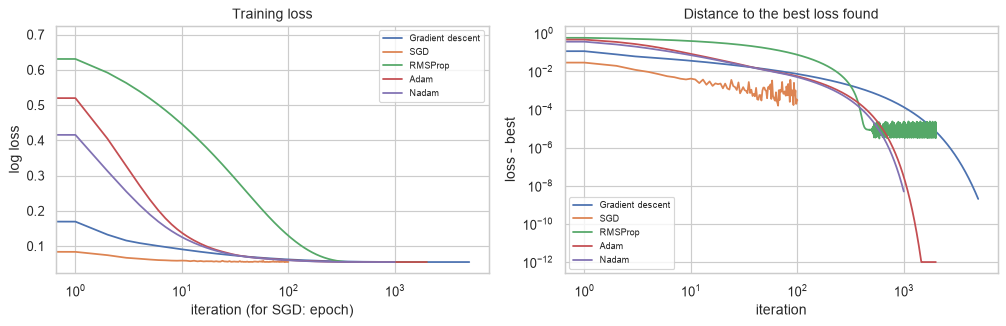

In [12]:
best_loss = min(history[-1] for history in histories.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    axes[0].plot(history, label=name)
    axes[1].plot(np.maximum(history - best_loss, 1e-12), label=name)

axes[0].set(title="Training loss", xlabel="iteration (for SGD: epoch)", ylabel="log loss", xscale="log")
axes[1].set(title="Distance to the best loss found", xlabel="iteration", ylabel="loss - best",
            xscale="log", yscale="log")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The picture repeats what Homework 5 found on a regression problem, which is reassuring: **Adam and Nadam reach the minimum to the last digit**, plain gradient descent gets there too but needs several thousand iterations, **RMSProp plateaus slightly above it** because its constant step never shrinks near the optimum, and **SGD oscillates** around the minimum instead of settling — its per-sample updates stay noisy at a fixed learning rate.

## Step 8: Logistic Regression Trained by a Genetic Algorithm

The genetic algorithm searches the same 11-dimensional weight space, but it knows nothing about gradients: a chromosome is a vector of 11 real numbers and its fitness is the negative loss.

In [13]:
def fitness_func(ga_instance, solution, solution_idx):
    """Negative training loss - PyGAD maximizes, so the best chromosome is the lowest loss."""
    return -log_loss(np.array(solution))


GA_POPULATION = 100
GA_GENERATIONS = 500

ga_instance = pygad.GA(
    num_generations=GA_GENERATIONS,
    num_parents_mating=20,
    fitness_func=fitness_func,
    sol_per_pop=GA_POPULATION,
    num_genes=N_WEIGHTS,
    init_range_low=-3,
    init_range_high=3,
    parent_selection_type="sss",
    keep_parents=4,
    crossover_type="two_points",
    mutation_type="random",
    mutation_percent_genes=10,
    random_mutation_min_val=-0.3,
    random_mutation_max_val=0.3,
    random_seed=RANDOM_STATE,
    suppress_warnings=True,
)

ga_instance.run()

ga_solution, ga_fitness, _ = ga_instance.best_solution()
weights["Genetic algorithm"] = np.array(ga_solution)

print(f"Best training loss found by the GA: {-ga_fitness:.8f}")
print(f"Best training loss found by Adam:   {histories['Adam'][-1]:.8f}")
print(f"Difference: {-ga_fitness - histories['Adam'][-1]:+.2e}")
print(f"Fitness evaluations used: {GA_POPULATION * GA_GENERATIONS:,}")

Best training loss found by the GA: 0.05468024
Best training loss found by Adam:   0.05467514
Difference: +5.10e-06
Fitness evaluations used: 50,000


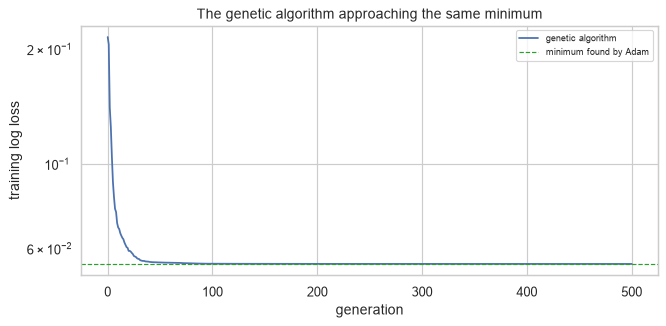

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(-np.array(ga_instance.best_solutions_fitness), label="genetic algorithm")
ax.axhline(best_loss, color="tab:green", linestyle="--", linewidth=1, label="minimum found by Adam")
ax.set(title="The genetic algorithm approaching the same minimum", xlabel="generation",
       ylabel="training log loss", yscale="log")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 9: Quality of Every Classifier

`confusion_matrix()` and `f1_score()` for all seven models on the same held-out test set. The two error columns are split apart because they are not equally serious: *malignant missed* is a cancer called benign.

In [15]:
summary = [report("sklearn LogisticRegression", sklearn_pred,
                  train_loss=log_loss(np.r_[sklearn_model.intercept_, sklearn_model.coef_.ravel()]),
                  cost="lbfgs, L2 by default", comment="baseline")]

COSTS = {"Gradient descent": "5000 gradient steps", "SGD": "100 epochs x 426 updates",
         "RMSProp": "2000 gradient steps", "Adam": "2000 gradient steps",
         "Nadam": "1000 gradient steps", "Genetic algorithm": f"{GA_POPULATION * GA_GENERATIONS:,} loss evaluations"}

for name, w in weights.items():
    summary.append(report(name, predict(w), train_loss=log_loss(w), cost=COSTS[name]))

summary = pd.DataFrame(summary).drop(columns="note")
summary.round(6)

,model,F1,accuracy,malignant missed,benign misflagged,train log loss,cost
0,sklearn LogisticRegression,0.983240,0.979021,1,2,0.060295,"lbfgs, L2 by default"
1,Gradient descent,0.977528,0.972028,1,3,0.054675,5000 gradient steps
2,SGD,0.977528,0.972028,1,3,0.054977,100 epochs x 426 updates
3,RMSProp,0.977528,0.972028,1,3,0.054681,2000 gradient steps
4,Adam,0.977528,0.972028,1,3,0.054675,2000 gradient steps
5,Nadam,0.977528,0.972028,1,3,0.054675,1000 gradient steps
6,Genetic algorithm,0.977528,0.972028,1,3,0.054680,"50,000 loss evaluations"


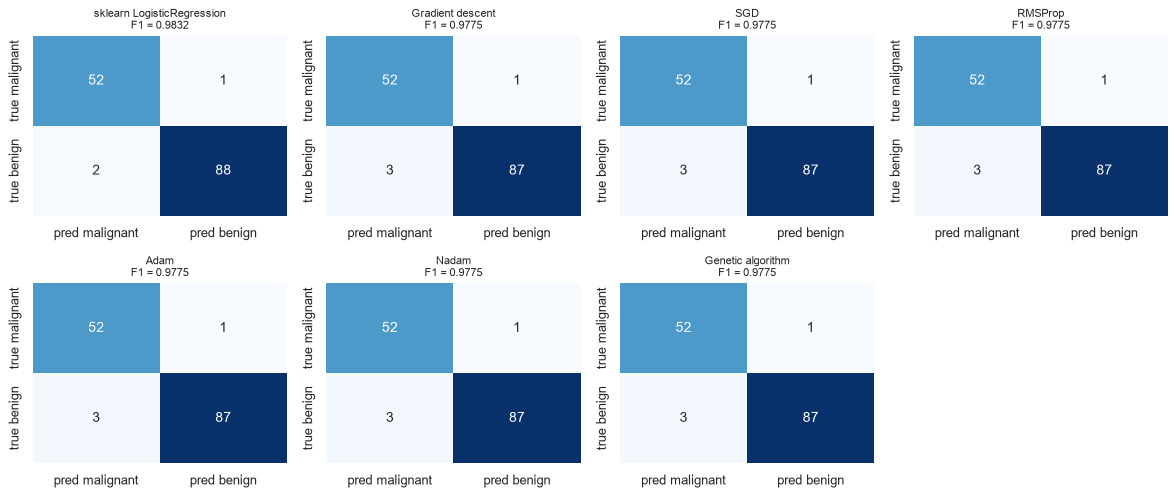

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
all_predictions = {"sklearn LogisticRegression": sklearn_pred}
all_predictions.update({name: predict(w) for name, w in weights.items()})

for ax, (name, prediction) in zip(axes.ravel(), all_predictions.items()):
    matrix = pd.DataFrame(confusion_matrix(y_test, prediction),
                          index=[f"true {n}" for n in class_names],
                          columns=[f"pred {n}" for n in class_names])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\nF1 = {f1_score(y_test, prediction):.4f}", fontsize=9)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

Six of the seven models produce **identical predictions** — same confusion matrix, same F1 of 0.9775. That is the expected outcome for a convex loss: they are all finding the same minimum, and only the route differs. The one that stands apart is scikit-learn's, with F1 0.9832 and one error fewer, despite a **higher** training loss than every hand-written optimizer.

A higher training loss and a better test score is the signature of regularization, not of a better optimizer. `LogisticRegression` applies L2 by default with `C=1.0`, which the implementations above do not. Turning it off should make the difference disappear.

In [17]:
regularization = []
for C in (1.0, 10.0, 1e6):
    model = LogisticRegression(C=C, max_iter=10000, random_state=RANDOM_STATE).fit(Z_train, y_train)
    w = np.r_[model.intercept_, model.coef_.ravel()]
    prediction = model.predict(Z_test)
    regularization.append({
        "C": C,
        "regularization": "default L2" if C == 1.0 else ("weak L2" if C == 10 else "effectively none"),
        "train log loss": log_loss(w),
        "test F1": f1_score(y_test, prediction),
        "weight norm": np.linalg.norm(w),
    })

regularization.append({"C": np.inf, "regularization": "none (own Adam)",
                       "train log loss": log_loss(weights["Adam"]),
                       "test F1": f1_score(y_test, predict(weights["Adam"])),
                       "weight norm": np.linalg.norm(weights["Adam"])})

pd.DataFrame(regularization).round(6)

,C,regularization,train log loss,test F1,weight norm
0,1.0,default L2,0.060295,0.983240,3.273955
1,10.0,weak L2,0.054972,0.977528,4.694919
2,1000000.0,effectively none,0.054675,0.977528,5.260350
3,inf,none (own Adam),0.054675,0.977528,5.263001


Confirmed: with regularization effectively removed, scikit-learn lands on a training loss of 0.05467514 — the same value, to all eight digits, that Adam and Nadam reach — and its test F1 falls to 0.9775, exactly matching the hand-written optimizers. The gap was never about optimization quality. It was one hyperparameter, and the noticeably smaller weights it produces (norm 3.27 against 5.26) generalize a little better.

## Step 10: Conclusions

**On optimization.** Every method tested — five hand-written gradient variants, a genetic algorithm, and scikit-learn's L-BFGS — converges to the same minimum of a convex loss, and six of the seven produce byte-identical predictions. What separates them is cost and reliability, not the answer:

| | iterations | final train loss | gap to the minimum |
| --- | --- | --- | --- |
| Nadam | 1000 | 0.05467514 | exact |
| Adam | 2000 | 0.05467514 | exact |
| Gradient descent | 5000 | 0.05467514 | exact |
| RMSProp | 2000 | 0.05468079 | $+6 \cdot 10^{-6}$ |
| Genetic algorithm | 50 000 evaluations | 0.05468024 | $+5 \cdot 10^{-6}$ |
| SGD | 100 epochs | 0.05497734 | $+3 \cdot 10^{-4}$ |

The adaptive methods are the clear winners: Nadam needs a fifth of the iterations of plain gradient descent for the same result. RMSProp stops just short, for the structural reason seen in Homework 5 — a step normalized by the gradient's own magnitude does not shrink near the optimum. SGD never settles at all; with a constant learning rate its per-sample updates keep it circling the minimum.

**On the genetic algorithm.** It gets within $5 \cdot 10^{-6}$ of the true minimum without using a single derivative, which is a genuine result — but it spends 50 000 loss evaluations to do what Nadam does in 1000 gradient steps. That is the honest trade: a gradient is an enormous amount of information, and when the loss is differentiable and convex, refusing to use it costs one to two orders of magnitude. The GA earns its place where gradients do not exist — the knapsack problem of Homework 11 — not here.

**On the pipeline.** Clustering with no labels already recovers the diagnosis at 94% accuracy (Gaussian mixture), which told us in advance that the classes are separable and a simple model would suffice. PCA compressed 30 features into 10 while keeping 95% of the variance, and the classifiers lose nothing by it. The final models reach **F1 0.977–0.983** with a single malignant case missed out of 53 — good, though in a diagnostic setting the decision threshold would be lowered deliberately to trade false alarms for fewer missed cancers.

**The one thing that actually changed test quality** was not an optimizer at all, but the L2 penalty: the same solution, fitted with slightly smaller weights, made one error fewer. Tuning the model mattered more than tuning the search for it.